# tf.keras.Sequential을 이용한 다양한 선형모형 풀이

## tf.keras.Sequential 사용방법 

### 예비학습: $x \to \hat{y}$ 가 되는 과정을 그림으로 그리기

`-` 단순회귀분석의 예시
- $\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i, \quad i=1,2,\dots,n$

In [2]:
import graphviz
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"'+s + '; }')

(아주 정확한 표현) 제가 진짜 한땀한땀 만들었어요 

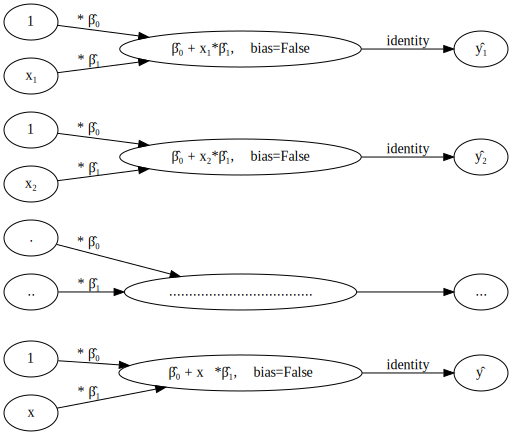

In [73]:
gv(''' 
    "1" -> "β̂₀ + xₙ*β̂₁,    bias=False"[label="* β̂₀"]
    "xₙ" -> "β̂₀ + xₙ*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + xₙ*β̂₁,    bias=False" -> "ŷₙ"[label="identity"]

    "." -> "...................................."[label="* β̂₀"]
    ".." -> "...................................."[label="* β̂₁"]
    "...................................." -> "..."[label=" "]

    "1 " -> "β̂₀ + x₂*β̂₁,    bias=False"[label="* β̂₀"]
    "x₂" -> "β̂₀ + x₂*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + x₂*β̂₁,    bias=False" -> "ŷ₂"[label="identity"]
    
    "1  " -> "β̂₀ + x₁*β̂₁,    bias=False"[label="* β̂₀"]
    "x₁" -> "β̂₀ + x₁*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + x₁*β̂₁,    bias=False" -> "ŷ₁"[label="identity"]
''')


`-` 감상? 
- 교수님이 고생한것 같음 
- 그런데 그냥 하나의 $x_i$에 대하여 하나만 만들고 복붙하면 되지 않나? 

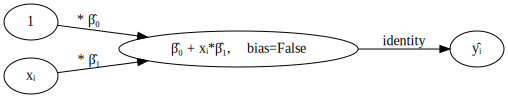

In [64]:
gv(''' 
    "1" -> "β̂₀ + xᵢ*β̂₁,    bias=False"[label="* β̂₀"]
    "xᵢ" -> "β̂₀ + xᵢ*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + xᵢ*β̂₁,    bias=False" -> "ŷᵢ"[label="identity"]

''')


`-` $i$ 역시 그냥 생략해도 될 듯. 어떠한 특정한 하나의 관측치를 가정하고 아래와 같이표현해도 ok

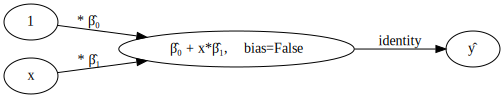

In [63]:
gv(''' 
    "1" -> "β̂₀ + x*β̂₁,    bias=False"[label="* β̂₀"]
    "x" -> "β̂₀ + x*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + x*β̂₁,    bias=False" -> "ŷ"[label="identity"]

''')


`-` 근데 이건 아래로 더 간단히 표현가능 

(표현2)

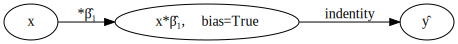

In [66]:
gv('''
"x" -> "x*β̂₁,    bias=True"[label="*β̂₁"] ;
"x*β̂₁,    bias=True" -> "ŷ"[label="indentity"] ''')


- 실제로는 이런식으로 많이 씀 

`-` 벡터로 표현하면 아래와 같음 

(표현3)

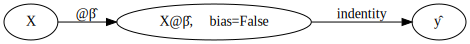

In [68]:
gv('''
"X" -> "X@β̂,    bias=False"[label="@β̂"] ;
"X@β̂,    bias=False" -> "ŷ"[label="indentity"] ''')


- 나는 이걸 좋아함 

`-` 딥러닝에서는 $\hat{\boldsymbol{\beta}}$ 을 $\hat{\bf W}$로 표현한다. 

(표현3)'

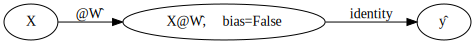

In [71]:
gv('''
"X" -> "X@Ŵ,    bias=False"[label="@Ŵ"] ;
"X@Ŵ,    bias=False" -> "ŷ"[label="identity"] ''')


`-` 실제로는 표현2 혹은 표현3을 외우면 된다. 

### Layer의 개념 

`-` (표현2) 혹은 (표현3) 의 과정은 레이어로 표현할 수 있다. 

`-` 레이어는 항상 아래와 같은 규칙을 가진다. (이게 사실 통계학의 GLM을 베낀거라고 생각해요)
- 첫 동그라미는 레이어의 입력이다. 
- 첫번째 화살표는 선형변환을 의미한다. 
- 두번째 동그라미는 선형변환의 결과이다. (이때 bias 가 false이냐 true 이냐에 따라서 실제수식이 조금 다름) 
- 두번째 화살표는 두번째 동그라미에 어떠한 함수 $f$를 취하는 것이다. (이 경우 $f(x)=x$) 
- 세번째 동그라미는 레이어의 최종출력이다. 

`-` 엄청 복잡해보이는데 결정할 것을 정리하면 아래의 3개이다. 
1. 레이어의 입력차원 
2. 선형변환 결과로 얻어지는 차원 
3. 선형변환에서 바이어스를 쓸지 안쓸지? 
4. 함수 $f$ 

`-` 주목: 1,3가 결정되면 자동으로 ${\bf \hat{W}}$의 차원이 결정된다. 

(예시)

- 입력차원2, 출력차원1: ${\bf W}$는 (2,1) 매트릭스 
- 입력차원20, 출력차원5: ${\bf W}$는 (20,5) 매트릭스 
- 입력차원2, 출력차원이50: ${\bf W}$는 (2,50) 매트릭스 

`-` 주목2: 이중에서 절대 생략불가능한 것은 "2. 선형변환 결과로 얻어지는 차원" 이다. 
- 레이어의 입력차원: 실제 레이어에 데이터가 들어올 때 데이터의 입력차원을 체크하여 스스로 알아낼 수 있다. 
- 바이어스를 쓸지 안 쓸지? 기본적으로 쓴다고 가정한다. 
- 함수 $f$: 기본적으로 항등함수를 가정한다. 

### Keras 문법 

`-` 기본뼈대: net생성 $\to$ add(layer) $\to$ compile(opt,loss) $\to$ fit(data,epoch) 

(0단계) 준비 

In [117]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

(1단계) net생성 

In [74]:
net = tf.keras.Sequential()

NameError: name 'tf' is not defined

(2단계) net.add(layer) 

(3단계) net.compile(opt,loss) 

(4단계) fit(data,epoch) 

In [118]:
alpha=0.1

In [119]:

net.add(tf.keras.layers.Dense(1,input_shape=(2,),use_bias=False)) 

In [120]:
def loss_fn2(y,yhat):
    loss = (y-yhat).T @ (y-yhat) / N
    return loss 

In [121]:
opt = tf.keras.optimizers.SGD(alpha)

In [122]:
net.compile(opt,loss=loss_fn2)

In [123]:
net.get_weights()

[array([[ 0.6924859],
        [-0.3262385]], dtype=float32)]

In [124]:
net.set_weights([np.array([-5.0,10.0]).reshape(2,1)])

In [125]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N)

In [126]:
net.get_weights()

[array([[2.58366 ],
        [3.933048]], dtype=float32)]

#### 풀이2: 벡터버전, net.compile의 옵션으로 손실함수 지정 

`-` 포인트
```python
## 포인트코드: 네트워크 컴파일 = 아키텍처 + 손실함수 + 옵티마이저
net.compile(opt,loss='mse') # net.compile의 옵션으로 손실함수 지정 
```

In [116]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [129]:
alpha=0.1

In [130]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1,input_shape=(2,),use_bias=False)) 

In [131]:
opt = tf.keras.optimizers.SGD(alpha)

In [132]:
net.compile(opt,loss='mse')

In [133]:
net.get_weights()

[array([[ 0.98623264],
        [-0.4947716 ]], dtype=float32)]

In [134]:
net.set_weights([np.array([-5.0,10.0]).reshape(2,1)])

In [135]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N)

In [136]:
net.get_weights()

[array([[2.58366 ],
        [3.933048]], dtype=float32)]

#### 풀이3: 스칼라버전, net.compile의 옵션으로 손실함수 지정 

`-` 포인트
```python
## 포인트코드: use_bias=True
net.add(tf.keras.layers.Dense(1,input_shape=(1,),use_bias=True)) 
```

In [239]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

In [240]:
alpha=0.1

In [241]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1,input_shape=(1,),use_bias=True)) 

In [242]:
opt = tf.keras.optimizers.SGD(alpha)

In [243]:
net.compile(opt,loss='mse')

In [244]:
net.get_weights()

[array([[-1.1765249]], dtype=float32), array([0.], dtype=float32)]

- [weight,bias] 순으로 출력

In [245]:
net.set_weights([np.array([[10.0]]),np.array([-5.0])])

In [246]:
net.get_weights()

[array([[10.]], dtype=float32), array([-5.], dtype=float32)]

In [247]:
net.fit(x,y,epochs=1000,verbose=0,batch_size=N)

In [248]:
net.get_weights()

[array([[3.933048]], dtype=float32), array([2.58366], dtype=float32)]